In [1]:
!pip install gensim

In [2]:
import re
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import random
from sklearn.neighbors import LocalOutlierFactor
from sklearn.neighbors import NearestNeighbors

In [3]:
articles_original = pd.read_csv('articles.csv')

In [4]:
articles = articles_original.copy()

In [5]:
articles_original.head()

,doc_id,text
0,DOC_00001,"When I first saw this, I thought for a second ..."
1,DOC_00002,The difficulties of a high Isp OTV include: Lo...
2,DOC_00003,"Forwarded from Neal Ausman, Galileo Mission Di..."
3,DOC_00004,Sjogren's syndrome has been known to induce dr...
4,DOC_00005,"Yes, I want to concentrate on other developmen..."


In [6]:
# load data

print(f" {len(articles)} total documents")

 2164 total documents


# **Task 1: Preprocessing**

In [7]:
# download nltk resources

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saram\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\saram\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saram\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\saram\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\saram\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\saram\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_pe

True

In [8]:
# clean text

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)      # remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip()    # remove multiple spaces
    return text

articles['cleaned'] = articles['text'].apply(clean_text)
articles

,doc_id,text,cleaned
0,DOC_00001,"When I first saw this, I thought for a second ...",when i first saw this i thought for a second t...
1,DOC_00002,The difficulties of a high Isp OTV include: Lo...,the difficulties of a high isp otv include lon...
2,DOC_00003,"Forwarded from Neal Ausman, Galileo Mission Di...",forwarded from neal ausman galileo mission dir...
3,DOC_00004,Sjogren's syndrome has been known to induce dr...,sjogren s syndrome has been known to induce dr...
4,DOC_00005,"Yes, I want to concentrate on other developmen...",yes i want to concentrate on other development...
...,...,...,...
2159,DOC_02160,Punch Imlach's contributions as a coach and GM...,punch imlach s contributions as a coach and gm...
2160,DOC_02161,I have a few reprints left of chapters from my...,i have a few reprints left of chapters from my...
2161,DOC_02162,"Tom Barrasso wore a great mask, one time, last...",tom barrasso wore a great mask one time last s...
2162,DOC_02163,PATRICK 1st rd: Pens over Isles in 4. Devils o...,patrick st rd pens over isles in devils over c...


In [9]:
# count most popular words

all_words = ' '.join(articles['cleaned']).split()
most_common = Counter(all_words).most_common(50)
for word, count in most_common:
    print(f"{word:<20} {count}")

the                  15480
to                   7518
a                    7177
of                   6366
i                    6052
and                  5940
in                   4709
is                   4400
that                 3922
it                   3899
for                  2958
you                  2507
on                   2393
s                    2133
be                   2129
this                 2065
have                 2031
t                    1983
are                  1851
with                 1766
was                  1716
but                  1669
not                  1652
as                   1613
if                   1501
or                   1469
at                   1439
they                 1385
can                  1230
only                 1168
would                1152
offer                1146
from                 1134
my                   1106
there                1063
he                   1055
will                 1017
an                   983
about       

In [10]:
# lemmatization and remove stopwords with nltk

lemmatizer = WordNetLemmatizer()

custom_stopwords = {
    'dont', 'doesnt', 'isnt', 'wasnt', 'wouldnt', 'shouldnt',
    'im', 'ive', 'id', 'youre', 'theyre', 'weve', 'hes', 'shes',
    'said', 'says', 'like', 'just', 'know', 'think', 'make', 'way',
    'would', 'one', 'get', 'also', 'good', 'could', 'well', 'much',
    'may', 'first', 'even', 'anyone', 'see', 'two', 'back', 'work',
    'need', 'right', 'use', 'thing', 'new','time', 'year', 'day',
    'many', 'really', 'something', 'lot', 'never', 'still', 'last',
    'long', 'ago', 'little', 'using', 'point', 'problem', 'people',
    'gordon', 'banks', 'geb', 'cadre', 'pitt', 'chastity', 'shameful',
    'skepticism', 'intellect', 'njxp','jxp', 'surrender', 'radius',
    'gif', 'lyme', 'dsl'
}
stop_words = set(stopwords.words('english')) | custom_stopwords

def lemmatize_and_filter(text):
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in stop_words and len(t) > 2
    ]
    return ' '.join(tokens)

articles['processed'] = articles['cleaned'].apply(lemmatize_and_filter)
articles

,doc_id,text,cleaned,processed
0,DOC_00001,"When I first saw this, I thought for a second ...",when i first saw this i thought for a second t...,saw thought second headline star plier found s...
1,DOC_00002,The difficulties of a high Isp OTV include: Lo...,the difficulties of a high isp otv include lon...,difficulty high isp otv include transfer time ...
2,DOC_00003,"Forwarded from Neal Ausman, Galileo Mission Di...",forwarded from neal ausman galileo mission dir...,forwarded neal ausman galileo mission director...
3,DOC_00004,Sjogren's syndrome has been known to induce dr...,sjogren s syndrome has been known to induce dr...,sjogren syndrome known induce dryness vaginal ...
4,DOC_00005,"Yes, I want to concentrate on other developmen...",yes i want to concentrate on other development...,yes want concentrate development issue created...
...,...,...,...,...
2159,DOC_02160,Punch Imlach's contributions as a coach and GM...,punch imlach s contributions as a coach and gm...,punch imlach contribution coach far greater co...
2160,DOC_02161,I have a few reprints left of chapters from my...,i have a few reprints left of chapters from my...,reprint left chapter book vision future includ...
2161,DOC_02162,"Tom Barrasso wore a great mask, one time, last...",tom barrasso wore a great mask one time last s...,tom barrasso wore great mask season unveiled g...
2162,DOC_02163,PATRICK 1st rd: Pens over Isles in 4. Devils o...,patrick st rd pens over isles in devils over c...,patrick pen isle devil cap pen devil adam sabr...


In [11]:
# count most popular words after lemmatization so to see if we have to remove other words

all_words = ' '.join(articles['processed']).split()
most_common = Counter(all_words).most_common(50)
for word, count in most_common:
    print(f"{word:<20} {count}")

offer                1175
deal                 970
pickup               897
sale                 764
fast                 760
bonus                661
item                 581
car                  547
cash                 495
coupon               481
game                 479
discount             470
limited              446
team                 443
space                422
http                 414
special              365
quick                345
ref                  339
code                 332
listing              317
system               290
promo                289
edu                  286
year                 280
want                 267
take                 267
since                266
buy                  264
player               264
better               247
look                 245
program              244
got                  242
price                234
thanks               231
used                 227
help                 226
might                226
play                 225

In [12]:
# Bag-of-words

bow_vectorizer = CountVectorizer(
    min_df=10,
    max_df=0.7,
    max_features=5000
)
bow_matrix = bow_vectorizer.fit_transform(articles['processed'])
print(f"Bag-of-words matrix shape: {bow_matrix.shape}")

Bag-of-words matrix shape: (2164, 2341)


In [13]:
# top 20 terms by average word count (bag-of-words)

print("\n Top 20 terms by average word count")
mean_bow = np.asarray(bow_matrix.mean(axis=0)).flatten()
bow_terms = bow_vectorizer.get_feature_names_out()
top_indices = mean_bow.argsort()[::-1][:20]
for i in top_indices:
    print(f"  {bow_terms[i]:<25} {mean_bow[i]:.4f}")


 Top 20 terms by average word count
  offer                     0.5430
  deal                      0.4482
  pickup                    0.4145
  sale                      0.3530
  fast                      0.3512
  bonus                     0.3055
  item                      0.2685
  car                       0.2528
  cash                      0.2287
  coupon                    0.2223
  game                      0.2213
  discount                  0.2172
  limited                   0.2061
  team                      0.2047
  space                     0.1950
  http                      0.1913
  special                   0.1687
  quick                     0.1594
  ref                       0.1567
  code                      0.1534


In [14]:
# Word2Vec

tokenized_docs = [doc.split() for doc in articles['processed']]

w2v_model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=100, 
    window=5,          
    min_count=5,
    workers=1, 
    epochs=10,
    seed=42
)

def get_doc_vector(doc, model):
    words = doc.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

w2v_matrix = np.array([get_doc_vector(doc, w2v_model) for doc in articles['processed']])

print(f" Word2Vec matrix shape: {w2v_matrix.shape}")

 Word2Vec matrix shape: (2164, 100)


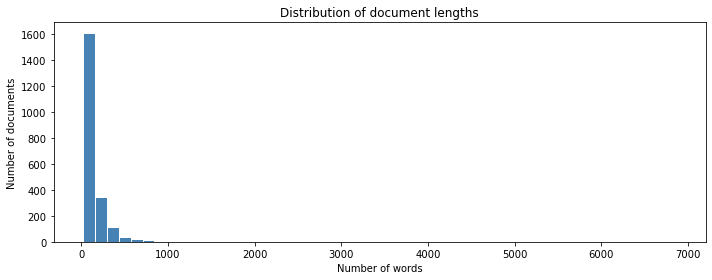


 Avg document length: 151 words
 Min: 25, Max: 6863


In [15]:
# distribution of document lengths

article_lengths = articles['text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 4))
plt.hist(article_lengths, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Number of words')
plt.ylabel('Number of documents')
plt.title('Distribution of document lengths')
plt.tight_layout()
plt.show()
print(f"\n Avg document length: {article_lengths.mean():.0f} words")
print(f" Min: {article_lengths.min()}, Max: {article_lengths.max()}")

# **Task 2: Clustering**

In [16]:
# reduce dimension of bow matrix

svd = TruncatedSVD(n_components=100, random_state=42)
normalizer = Normalizer(copy=False)
lsa = make_pipeline(svd, normalizer)

bow_matrix_reduced = lsa.fit_transform(bow_matrix)
print(f" Reduced matrix shape: {bow_matrix_reduced.shape}")

 Reduced matrix shape: (2164, 100)


In [17]:
k_values = range(2, 11)

In [18]:
# K-means with different k on bow matrix + svd

print("\n Silhouette Scores (K-Means, BoW + SVD)")
silhouette_scores_bow = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(bow_matrix_reduced)
    score = silhouette_score(bow_matrix_reduced, labels, sample_size=500,random_state=42)
    silhouette_scores_bow.append(score)
    print(f"  k={k} Silhouette Score: {score:.4f}")


 Silhouette Scores (K-Means, BoW + SVD)
  k=2 Silhouette Score: 0.0480
  k=3 Silhouette Score: 0.0663
  k=4 Silhouette Score: 0.0771
  k=5 Silhouette Score: 0.0817
  k=6 Silhouette Score: 0.0881
  k=7 Silhouette Score: 0.0948
  k=8 Silhouette Score: 0.0984
  k=9 Silhouette Score: 0.0981
  k=10 Silhouette Score: 0.0963


In [19]:
# K-means with different k on word2vec matrix

print("\n Silhouette Scores (K-Means, Word2Vec)")
silhouette_scores_w2v = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(w2v_matrix)
    score = silhouette_score(w2v_matrix, labels, sample_size=500,random_state=42)
    silhouette_scores_w2v.append(score)
    print(f"  k={k} → Silhouette Score: {score:.4f}")


 Silhouette Scores (K-Means, Word2Vec)
  k=2 → Silhouette Score: 0.8560
  k=3 → Silhouette Score: 0.4901
  k=4 → Silhouette Score: 0.4009
  k=5 → Silhouette Score: 0.4003
  k=6 → Silhouette Score: 0.3921
  k=7 → Silhouette Score: 0.3933
  k=8 → Silhouette Score: 0.3351
  k=9 → Silhouette Score: 0.2148
  k=10 → Silhouette Score: 0.1878


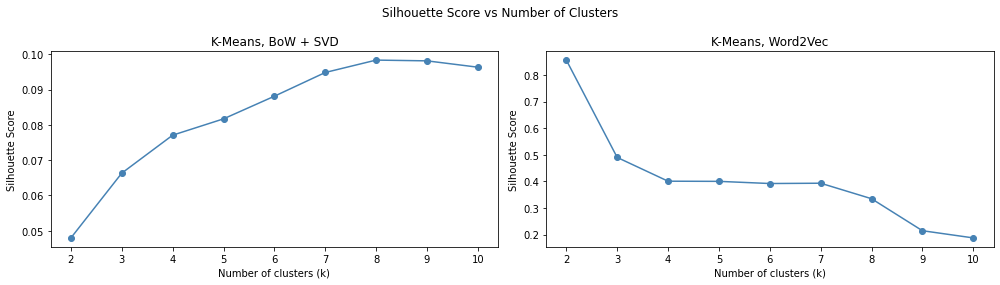

In [20]:
# plot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(k_values, silhouette_scores_bow, marker='o', color='steelblue')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('K-Means, BoW + SVD')

ax2.plot(k_values, silhouette_scores_w2v, marker='o', color='steelblue')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('K-Means, Word2Vec')


plt.suptitle('Silhouette Score vs Number of Clusters')
plt.tight_layout()
plt.savefig('silhouette_k.png', dpi=150)
plt.show()

In [21]:
# top terms per cluster for k=8 and k=9 for bow + svd

bow_terms = bow_vectorizer.get_feature_names_out()

print("\n K-Means (k=8, BoW + SVD)")
kmeans_8 = KMeans(n_clusters=8, random_state=42, n_init=10)
labels_8 = kmeans_8.fit_predict(bow_matrix_reduced)

for i in range(8):
    cluster_docs = bow_matrix[labels_8 == i]
    mean_counts = np.asarray(cluster_docs.mean(axis=0)).flatten()
    top_indices = mean_counts.argsort()[::-1][:10]
    top_terms = [bow_terms[j] for j in top_indices]
    print(f"Cluster {i} ({(labels_8 == i).sum()} docs): {', '.join(top_terms)}")

print("\n K-Means (k=9, BoW + SVD)")
kmeans_9 = KMeans(n_clusters=9, random_state=42, n_init=10)
labels_9 = kmeans_9.fit_predict(bow_matrix_reduced)

for i in range(9):
    cluster_docs = bow_matrix[labels_9 == i]
    mean_counts = np.asarray(cluster_docs.mean(axis=0)).flatten()
    top_indices = mean_counts.argsort()[::-1][:9]
    top_terms = [bow_terms[j] for j in top_indices]
    print(f"Cluster {i} ({(labels_9 == i).sum()} docs): {', '.join(top_terms)}")


 K-Means (k=8, BoW + SVD)
Cluster 0 (607 docs): system, science, water, van, cost, year, used, data, say, high
Cluster 1 (359 docs): file, image, graphic, program, thanks, help, please, window, color, format
Cluster 2 (53 docs): offer, pickup, deal, sale, fast, bonus, item, cash, coupon, discount
Cluster 3 (356 docs): game, team, player, hockey, play, season, goal, nhl, playoff, win
Cluster 4 (134 docs): space, nasa, station, launch, cost, program, shuttle, satellite, option, technology
Cluster 5 (225 docs): car, engine, dealer, model, price, speed, mile, look, drive, road
Cluster 6 (137 docs): edu, soon, corn, university, since, let, blood, patient, com, without
Cluster 7 (293 docs): food, patient, doctor, pain, msg, disease, cause, effect, treatment, medical

 K-Means (k=9, BoW + SVD)
Cluster 0 (280 docs): food, patient, doctor, pain, msg, disease, cause, effect, treatment
Cluster 1 (53 docs): offer, pickup, deal, sale, fast, bonus, item, cash, coupon
Cluster 2 (224 docs): car, engi

In [22]:
# top terms per cluster for k=8 for word2vec

print("\n K-Means (k=8, Word2Vec)")
kmeans_w2v = KMeans(n_clusters=8, random_state=42, n_init=10)
labels_w2v = kmeans_w2v.fit_predict(w2v_matrix)

for i in range(8):
    cluster_docs = bow_matrix[labels_w2v == i]
    mean_counts = np.asarray(cluster_docs.mean(axis=0)).flatten()
    top_indices = mean_counts.argsort()[::-1][:10]
    top_terms = [bow_terms[j] for j in top_indices]
    print(f"Cluster {i} ({(labels_w2v == i).sum()} docs): {', '.join(top_terms)}")


 K-Means (k=8, Word2Vec)
Cluster 0 (73 docs): edu, soon, space, university, mail, send, please, auto, address, rec
Cluster 1 (17 docs): pickup, deal, cash, fast, offer, discount, limited, sale, bonus, quick
Cluster 2 (237 docs): team, game, hockey, van, play, player, det, bos, chi, tor
Cluster 3 (1268 docs): car, space, year, system, since, want, food, take, cost, used
Cluster 4 (346 docs): image, graphic, file, thanks, program, help, please, window, color, system
Cluster 5 (16 docs): listing, offer, deal, bonus, sale, promo, buy, fast, code, ref
Cluster 6 (190 docs): game, team, player, season, play, hockey, goal, nhl, playoff, win
Cluster 7 (17 docs): offer, coupon, http, item, deal, ref, sale, bundle, pickup, clearance


In [23]:
kmeans_final = kmeans_8
labels_kmeans = labels_8

score_kmeans = silhouette_score(bow_matrix_reduced, labels_kmeans, sample_size=500,random_state=42)
print(f"\nSilhouette Score (K-Means, k=8): {score_kmeans:.4f}")


Silhouette Score (K-Means, k=8): 0.0984


In [24]:
# show 3 representative documents per cluster

print("\n 3 representative documents per cluster")
for i in range(8):
        print(f"\n ")
        print(f"CLUSTER {i} ({(labels_kmeans == i).sum()} docs)")
        cluster_indices = np.where(labels_kmeans == i)[0]
        for idx in cluster_indices[:3]:
            print(f"\n--- DOC {articles['doc_id'].iloc[idx]} ---")
            print(articles['text'].iloc[idx][:300])


 3 representative documents per cluster

 
CLUSTER 0 (607 docs)

--- DOC DOC_00002 ---
The difficulties of a high Isp OTV include: Long transfer times (radiation damage from VanAllen belts for both the spacecraft and OTV Arcjets or Xenon thrusters require huge amounts of power so you have to have either nuclear power source (messy, dangerous and source of radiation damage) or BIG sola

--- DOC DOC_00003 ---
Forwarded from Neal Ausman, Galileo Mission Director GALILEO MISSION DIRECTOR STATUS REPORT POST-LAUNCH April 9 - 15, 1993 SPACECRAFT 1. On April 9, real-time commands were sent, as planned, to reacquire celestial reference after completion of the Low Gain Antenna (LGA-2) swing/Dual Drive Actuator (

--- DOC DOC_00007 ---
SEI Level 5 (the highest level -- the SEI stands for Software Engineering Institute). I'm not sure, but I believe that this rating only applies to the flight software. Also keep in mind that it was *not* achieved through the use of sophisticated tools, but rather 


 Hierarchical Clustering (k=8)


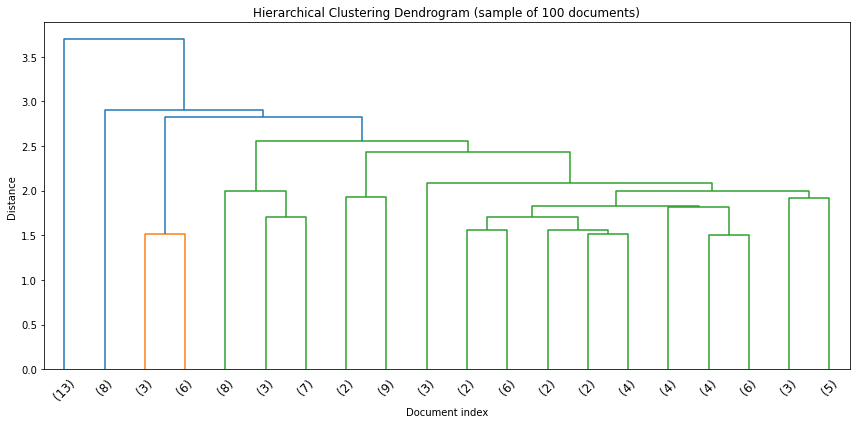

Cluster 0 (845 docs): space, year, food, patient, since, take, water, doctor, system, cost
Cluster 1 (411 docs): image, graphic, file, program, system, thanks, software, help, please, window
Cluster 2 (293 docs): car, engine, model, price, speed, dealer, oil, power, drive, mile
Cluster 3 (281 docs): team, player, game, hockey, play, season, win, nhl, goal, playoff
Cluster 4 (116 docs): edu, soon, corn, university, since, seizure, blood, might, case, com
Cluster 5 (50 docs): offer, pickup, deal, sale, fast, bonus, item, cash, coupon, discount
Cluster 6 (79 docs): space, nasa, station, idea, post, sci, might, program, shuttle, billboard
Cluster 7 (89 docs): game, team, abc, playoff, hockey, play, season, espn, coverage, goal

Silhouette Score (Hierarchical, k=8): 0.0717


In [25]:
print("\n Hierarchical Clustering (k=8)")

# plot a dendrogram on a sample of 100 documents to choose the number of clusters

sample_indices = np.random.choice(bow_matrix_reduced.shape[0], 100, replace=False)
sample_matrix = bow_matrix_reduced[sample_indices]
linked = linkage(sample_matrix, method='ward')


plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45)
plt.title('Hierarchical Clustering Dendrogram (sample of 100 documents)')
plt.xlabel('Document index')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()

# apply hierarchical clustering with k=8, show top terms per cluster

hierarchical = AgglomerativeClustering(n_clusters=8)
labels_hierarchical = hierarchical.fit_predict(bow_matrix_reduced)

for i in range(8):
    cluster_docs = bow_matrix[labels_hierarchical == i]
    mean_counts = np.asarray(cluster_docs.mean(axis=0)).flatten()
    top_indices = mean_counts.argsort()[::-1][:10]
    top_terms = [bow_terms[j] for j in top_indices]
    print(f"Cluster {i} ({(labels_hierarchical == i).sum()} docs): {', '.join(top_terms)}")

# silhouette score

score_hierarchical = silhouette_score(bow_matrix_reduced, labels_hierarchical, sample_size=500,random_state=42)
print(f"\nSilhouette Score (Hierarchical, k=8): {score_hierarchical:.4f}")

In [26]:
# spectral clustering (k=8)

print("\n Spectral Clustering (k=8)")

spectral = SpectralClustering(
    n_clusters=8,
    random_state=42,
    affinity='nearest_neighbors',
    n_neighbors=10,
    assign_labels='kmeans'
)
labels_spectral = spectral.fit_predict(bow_matrix_reduced)

for i in range(8):
    cluster_docs = bow_matrix[labels_spectral == i]
    mean_counts = np.asarray(cluster_docs.mean(axis=0)).flatten()
    top_indices = mean_counts.argsort()[::-1][:10]
    top_terms = [bow_terms[j] for j in top_indices]
    print(f"Cluster {i} ({(labels_spectral == i).sum()} docs): {', '.join(top_terms)}")

score_spectral = silhouette_score(bow_matrix_reduced, labels_spectral, sample_size=500,random_state=42)
print(f"\n Silhouette Score (Spectral, k=8): {score_spectral:.4f}")


 Spectral Clustering (k=8)
Cluster 0 (1357 docs): space, system, edu, program, image, graphic, help, year, thanks, want
Cluster 1 (17 docs): listing, offer, deal, bonus, sale, promo, buy, fast, code, ref
Cluster 2 (17 docs): offer, coupon, http, item, deal, ref, sale, bundle, pickup, clearance
Cluster 3 (21 docs): pickup, deal, cash, fast, offer, discount, limited, sale, bonus, quick
Cluster 4 (372 docs): game, team, player, hockey, play, season, goal, win, nhl, playoff
Cluster 5 (12 docs): captain, traded, leaf, buffalo, season, team, subject, ever, edmonton, mike
Cluster 6 (276 docs): car, engine, model, dealer, price, speed, mile, drive, look, power
Cluster 7 (92 docs): food, msg, pain, doctor, cause, chinese, study, effect, told, restaurant

 Silhouette Score (Spectral, k=8): 0.0709


In [27]:
# summary

print(f"  K-Means (k=8):      {score_kmeans:.4f}")
print(f"  Hierarchical (k=8): {score_hierarchical:.4f}")
print(f"  Spectral (k=8):     {score_spectral:.4f}")

  K-Means (k=8):      0.0984
  Hierarchical (k=8): 0.0717
  Spectral (k=8):     0.0709


In [28]:
# save clusters.csv

clusters_df = pd.DataFrame({
    'doc_id': articles['doc_id'],
    'cluster': labels_kmeans
})
clusters_df.to_csv('clusters.csv', index=False)

# **Task 3: Anomaly Detection**

In [29]:
# extract structural features

def extract_features(text):
    if not isinstance(text, str):
        return [0, 0, 0, 0, 0]
    
    words = text.split()
    total_words = len(words)
    unique_words = len(set(words))
    avg_word_length = np.mean([len(w) for w in words]) if words else 0
    lexical_diversity = unique_words / total_words if total_words > 0 else 0
    avg_sentence_length = total_words / (text.count('.') + 1)
    
    return [total_words, unique_words, avg_word_length, lexical_diversity, avg_sentence_length]

feature_names_anomaly = [
    'total_words', 
    'unique_words', 
    'avg_word_length', 
    'lexical_diversity',
    'avg_sentence_length'
]

features_df = pd.DataFrame(
    [extract_features(text) for text in articles['text']],
    columns=feature_names_anomaly
)

print(features_df.describe())

       total_words  unique_words  avg_word_length  lexical_diversity  \
count  2164.000000   2164.000000      2164.000000        2164.000000   
mean    151.219039    100.489372         4.962849           0.765883   
std     228.399709     99.489559         1.551923           0.121548   
min      25.000000     22.000000         1.961134           0.113924   
25%      59.000000     49.000000         4.421053           0.707922   
50%      95.000000     74.000000         4.707241           0.779316   
75%     165.000000    116.000000         5.112932           0.845326   
max    6863.000000   1775.000000        24.958763           1.000000   

       avg_sentence_length  
count          2164.000000  
mean             14.464921  
std              16.353259  
min               1.326316  
25%               9.216667  
50%              12.639610  
75%              16.666667  
max             424.000000  


In [30]:
# normalize features

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_df)

print(f" Feature matrix shape: {features_scaled.shape}")

 Feature matrix shape: (2164, 5)


In [31]:
# apply isolation forest

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=50/2164,
    random_state=42
)
iso_labels = iso_forest.fit_predict(features_scaled) # -1 = anomaly, 1 = normal
iso_scores = iso_forest.decision_function(features_scaled)

# show top 10 most anomalous documents

anomaly_df = pd.DataFrame({
    'doc_id': articles['doc_id'].values,
    'anomaly_score': iso_scores,
    'label': iso_labels
})
anomaly_df = anomaly_df.sort_values('anomaly_score')
print("\n Top 10 most anomalous documents")
print(anomaly_df.head(10))


 Top 10 most anomalous documents
         doc_id  anomaly_score  label
1715  DOC_01716      -0.151487     -1
2076  DOC_02077      -0.136920     -1
1036  DOC_01037      -0.112005     -1
1686  DOC_01687      -0.111544     -1
533   DOC_00534      -0.110544     -1
88    DOC_00089      -0.101134     -1
872   DOC_00873      -0.099158     -1
1876  DOC_01877      -0.096297     -1
97    DOC_00098      -0.095705     -1
745   DOC_00746      -0.087197     -1


In [32]:
# inspect top 5 most anomalous documents

print("Top 5 most anomalous documents")
for idx, row in anomaly_df.head(5).iterrows():
    print(f"\n {row['doc_id']} (score: {row['anomaly_score']:.4f})")
    print(articles['text'].iloc[idx][:300])

Top 5 most anomalous documents

 DOC_01716 (score: -0.1515)
Individual leaders by total points (Final standings) NOTE: Games played and points per games not accurate !! Player Team GP G A Pts ppg Prj PIM +/- M.Lemieux PIT 59 69 91 160 2.71 160 38 53 LaFontaine BUF 82 53 95 148 1.80 148 63 13 Oates BOS 83 45 97 142 1.71 142 32 12 Yzerman DET 83 58 79 137 1.65

 DOC_02077 (score: -0.1369)
Playoff leaders as of April 19, 1993 Player Team GP G A Pts +/- PIM M.Lemieux PIT 1 2 2 4 0 0 Juneau BOS 1 1 3 4 0 0 Noonan CHI 1 3 0 3 0 0 Mogilny BUF 1 2 1 3 0 0 Neely BOS 1 2 1 3 0 0 Brown STL 1 1 2 3 0 0 Jagr PIT 1 1 2 3 0 0 Oates BOS 1 0 3 3 0 0 Carson LA 1 2 0 2 0 0 Hunter WAS 1 2 0 2 0 0 Stev

 DOC_01037 (score: -0.1120)
The FLYERS blew a 3-0 lead over the Buffalo Sabres in the second period, but Kevin Dineen's 7th career hat trick powered them to their 7th consecutive win, 7-4 over the Sabres who have now lost 7 in a row. Alexander Mogilny led the comeback scoring his 75th and 76th goals of the 

In [33]:
# inspect all anomalous documents found by isolation forest 

anomalous_ids = anomaly_df[anomaly_df['label'] == -1]['doc_id']
for doc_id in anomalous_ids:
    idx = articles[articles['doc_id'] == doc_id].index[0]
    print(f"\n {doc_id}")
    print(articles['text'].iloc[idx][:400])


 DOC_01716
Individual leaders by total points (Final standings) NOTE: Games played and points per games not accurate !! Player Team GP G A Pts ppg Prj PIM +/- M.Lemieux PIT 59 69 91 160 2.71 160 38 53 LaFontaine BUF 82 53 95 148 1.80 148 63 13 Oates BOS 83 45 97 142 1.71 142 32 12 Yzerman DET 83 58 79 137 1.65 137 44 33 Turgeon NYI 80 58 74 132 1.65 132 26 -2 Selanne WIN 82 76 56 132 1.61 132 45 6 Mogilny BU

 DOC_02077
Playoff leaders as of April 19, 1993 Player Team GP G A Pts +/- PIM M.Lemieux PIT 1 2 2 4 0 0 Juneau BOS 1 1 3 4 0 0 Noonan CHI 1 3 0 3 0 0 Mogilny BUF 1 2 1 3 0 0 Neely BOS 1 2 1 3 0 0 Brown STL 1 1 2 3 0 0 Jagr PIT 1 1 2 3 0 0 Oates BOS 1 0 3 3 0 0 Carson LA 1 2 0 2 0 0 Hunter WAS 1 2 0 2 0 0 Stevens NJ 1 2 0 2 0 0 Cullen TOR 1 1 1 2 0 0 Hull STL 1 1 1 2 0 0 Khristich WAS 1 1 1 2 0 0 Linden VAN 

 DOC_01037
The FLYERS blew a 3-0 lead over the Buffalo Sabres in the second period, but Kevin Dineen's 7th career hat trick powered them to their 7th consecutive win, 7-4 ov

In [34]:
# inspect a listing document in full to confirm it contains anomaly content

idx = articles[articles['doc_id'] == 'DOC_00576'].index[0]
print(articles['text'].iloc[idx])

LISTING_ID_021 Second-hand bike, refurbished, collection in Bruges, around 120 euro. serious offers only. cash on pickup. no major defects. minor signs of use. serious offers only. Contact: fastdeal.contact@example.com or 0444/20.55.87. http://claim-discount-now.co/item/616/offer/7727/coupon/54 http://trusted-sales-direct.shop/item/918/offer/6644/coupon/84 http://trusted-sales-direct.shop/item/830/offer/8670/coupon/30 http://clearance-deals.net/item/237/offer/3246/coupon/71 http://bonus-marketplace.org/item/521/offer/1081/coupon/70 http://pickup-offer-fast.info/item/783/offer/2014/coupon/36 http://clearance-deals.net/item/355/offer/9309/coupon/53 http://pickup-offer-fast.info/item/345/offer/3383/coupon/69 http://deal-bundle-now.biz/item/771/offer/7632/coupon/52 http://clearance-deals.net/item/750/offer/8277/coupon/55 http://clearance-deals.net/item/740/offer/9288/coupon/30 http://clearance-deals.net/item/764/offer/3986/coupon/73 http://trusted-sales-direct.shop/item/339/offer/1380/coup

In [35]:
# version 2: adding has_listing feature and digit_ratio

def extract_features_v2(text):
    if not isinstance(text, str):
        return [0, 0, 0, 0, 0, 0]
    
    words = text.split()
    total_words = len(words)
    unique_words = len(set(words))
    avg_word_length = np.mean([len(w) for w in words]) if words else 0
    lexical_diversity = unique_words / total_words if total_words > 0 else 0
    avg_sentence_length = total_words / (text.count('.') + 1)
    has_listing = 1 if text.strip().startswith('LISTING_ID_') else 0
    digit_ratio = sum(c.isdigit() for c in text) / len(text) if len(text) > 0 else 0
    
    return [total_words, unique_words, avg_word_length, lexical_diversity, 
            avg_sentence_length, has_listing, digit_ratio]

feature_names_v2 = [
    'total_words', 'unique_words', 'avg_word_length', 
    'lexical_diversity', 'avg_sentence_length', 'has_listing', 'digit_ratio'
]

features_df_v2 = pd.DataFrame(
    [extract_features_v2(text) for text in articles['text']],
    columns=feature_names_v2
)
print(features_df_v2.describe())

       total_words  unique_words  avg_word_length  lexical_diversity  \
count  2164.000000   2164.000000      2164.000000        2164.000000   
mean    151.219039    100.489372         4.962849           0.765883   
std     228.399709     99.489559         1.551923           0.121548   
min      25.000000     22.000000         1.961134           0.113924   
25%      59.000000     49.000000         4.421053           0.707922   
50%      95.000000     74.000000         4.707241           0.779316   
75%     165.000000    116.000000         5.112932           0.845326   
max    6863.000000   1775.000000        24.958763           1.000000   

       avg_sentence_length  has_listing  digit_ratio  
count          2164.000000  2164.000000  2164.000000  
mean             14.464921     0.023105     0.013053  
std              16.353259     0.150273     0.030811  
min               1.326316     0.000000     0.000000  
25%               9.216667     0.000000     0.000000  
50%              12.6

In [36]:
features_scaled_v2 = scaler.fit_transform(features_df_v2)
print(f"\n Feature matrix shape (v2): {features_scaled_v2.shape}")


 Feature matrix shape (v2): (2164, 7)


In [37]:
# isolation forest v2

iso_forest_v2 = IsolationForest(
    n_estimators=100,
    contamination=50/2164,
    random_state=42
)
iso_labels_v2 = iso_forest_v2.fit_predict(features_scaled_v2)
iso_scores_v2 = iso_forest_v2.decision_function(features_scaled_v2)

anomaly_df_v2 = pd.DataFrame({
    'doc_id': articles['doc_id'].values,
    'anomaly_score': iso_scores_v2,
    'label': iso_labels_v2
})
anomaly_df_v2 = anomaly_df_v2.sort_values('anomaly_score')

print("\n Top 10 most anomalous documents")
print(anomaly_df_v2.head(10))


 Top 10 most anomalous documents
         doc_id  anomaly_score  label
1715  DOC_01716      -0.121395     -1
2076  DOC_02077      -0.096906     -1
1068  DOC_01069      -0.091507     -1
533   DOC_00534      -0.090615     -1
1686  DOC_01687      -0.090615     -1
575   DOC_00576      -0.083832     -1
2033  DOC_02034      -0.082307     -1
1751  DOC_01752      -0.081291     -1
358   DOC_00359      -0.080277     -1
415   DOC_00416      -0.076235     -1


In [38]:
# inspect top 10 most anomalous documents found bi isolation forst v2

for idx, row in anomaly_df_v2.head(10).iterrows():
    print(f"\n {row['doc_id']} (score: {row['anomaly_score']:.4f})")
    print(articles['text'].iloc[idx][:300])


 DOC_01716 (score: -0.1214)
Individual leaders by total points (Final standings) NOTE: Games played and points per games not accurate !! Player Team GP G A Pts ppg Prj PIM +/- M.Lemieux PIT 59 69 91 160 2.71 160 38 53 LaFontaine BUF 82 53 95 148 1.80 148 63 13 Oates BOS 83 45 97 142 1.71 142 32 12 Yzerman DET 83 58 79 137 1.65

 DOC_02077 (score: -0.0969)
Playoff leaders as of April 19, 1993 Player Team GP G A Pts +/- PIM M.Lemieux PIT 1 2 2 4 0 0 Juneau BOS 1 1 3 4 0 0 Noonan CHI 1 3 0 3 0 0 Mogilny BUF 1 2 1 3 0 0 Neely BOS 1 2 1 3 0 0 Brown STL 1 1 2 3 0 0 Jagr PIT 1 1 2 3 0 0 Oates BOS 1 0 3 3 0 0 Carson LA 1 2 0 2 0 0 Hunter WAS 1 2 0 2 0 0 Stev

 DOC_01069 (score: -0.0915)
LISTING_ID_002 Second-hand car, used, collection in Bruges, around 850 euro. minor signs of use. charger included. serious offers only. no major defects. Contact: usedgoods.reply@example.com or 0415/76.90.11. http://deal-bundle-now.biz/item/473/offer/4349/coupon/73 http://clearance-deals.net/item/31

 DOC_0053

In [39]:
# how many articles have LISTING_ID_ in the dataset

listing_docs = articles[articles['text'].str.startswith('LISTING_ID_', na=False)]
print(f"Documents with LISTING_ID_: {len(listing_docs)}")

Documents with LISTING_ID_: 50


In [40]:
# lof

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=50/2164,   
    novelty=False
)

lof_labels = lof.fit_predict(features_scaled_v2)
lof_scores = lof.negative_outlier_factor_

# top 10 most anomalous

lof_df = pd.DataFrame({
    'doc_id': articles['doc_id'].values,
    'lof_score': lof_scores,
    'label': lof_labels
})
lof_df = lof_df.sort_values('lof_score')
print("\n Top 10 most anomalous documents (LOF)")
print(lof_df.head(10))


 Top 10 most anomalous documents (LOF)
         doc_id  lof_score  label
88    DOC_00089 -10.506327     -1
97    DOC_00098  -8.816526     -1
1715  DOC_01716  -8.649236     -1
534   DOC_00535  -8.244370     -1
2076  DOC_02077  -5.493746     -1
533   DOC_00534  -5.422331     -1
1686  DOC_01687  -5.233436     -1
714   DOC_00715  -4.196824     -1
177   DOC_00178  -4.176021     -1
1036  DOC_01037  -3.890406     -1


In [41]:
# inspect top 5 most anomalous documents found by lof (structural features)

print("Top 5 most anomalous documents (LOF, structural features)")
for idx, row in lof_df.head(5).iterrows():
    print(f"\n {row['doc_id']} (score: {row['lof_score']:.4f})")
    print(articles['text'].iloc[idx][:500])

Top 5 most anomalous documents (LOF, structural features)

 DOC_00089 (score: -10.5063)
AHL CALDER CUP PLAYOFF GAME(S) PLAYED ON 4/16 Providence 3 SPRINGFIELD 2 (OT) Baltimore 4 BINGHAMTON 3 Utica 3 ROCHESTER 2 (OT) Cape Breton 5 FREDERICTON 2 GAME(S) SCHEDULED FOR 4/17 Capital District at Adirondack Providence at Springfield Baltimore at Binghamton Utica at Rochester Moncton vs St John's at Halifax SERIES STATI (plural of status? :) Adirondack leads CDI, 1-0 Springfield leads Providence, 2-1 Baltimore leads Binghamton 1-0 Utica leads Rochester, 1-0 St John's leads Moncton, 1-0 Cap

 DOC_00098 (score: -8.8165)
GAME(S) OF 4/15 --------------- ADIRONDACK 6 CDI 2 (Adirondack leads series, 1-0) ================================================= FIRST ROUND Springfield Indians vs Providence Bruins Gm 1: Springfield 3 PROVIDENCE 2 Gm 2: Springfield 5 PROVIDENCE 4 Gm 3: 4/16 Providence at Springfield Gm 4: 4/17 Providence at Springfield Gm 5: 4/22 Springfield at Providence * Gm 6: 4/24 Provide

In [42]:
listing_anomalies = set(listing_docs['doc_id'].values)

In [43]:
# overlap with listing documents for lof on structural features

lof_anomalies = set(lof_df[lof_df['label'] == -1]['doc_id'].values)
overlap = lof_anomalies & listing_anomalies
print(f" Listing documents found by LOF: {len(overlap)} out of 50")

 Listing documents found by LOF: 0 out of 50


In [44]:
# lof on bow + svd matrix

lof_bow = LocalOutlierFactor(
    n_neighbors=20,
    contamination=50/2164,
    novelty=False
)

lof_labels_bow = lof_bow.fit_predict(bow_matrix_reduced)
lof_scores_bow = lof_bow.negative_outlier_factor_

lof_df_bow = pd.DataFrame({
    'doc_id': articles['doc_id'].values,
    'lof_score': lof_scores_bow,
    'label': lof_labels_bow
})
lof_df_bow = lof_df_bow.sort_values('lof_score')

print("\n Top 10 most anomalous documents (LOF, BoW)")
print(lof_df_bow.head(10))


 Top 10 most anomalous documents (LOF, BoW)
         doc_id  lof_score  label
2031  DOC_02032  -1.664401     -1
762   DOC_00763  -1.658982     -1
1263  DOC_01264  -1.567595     -1
1774  DOC_01775  -1.547855     -1
807   DOC_00808  -1.547855     -1
1475  DOC_01476  -1.522388     -1
24    DOC_00025  -1.521747     -1
430   DOC_00431  -1.509331     -1
1054  DOC_01055  -1.494259     -1
819   DOC_00820  -1.482393     -1


In [45]:
# overlap with listing documents for lof on bow + svd matrix

lof_bow_anomalies = set(lof_df_bow[lof_df_bow['label'] == -1]['doc_id'].values)
overlap_bow = lof_bow_anomalies & listing_anomalies
print(f"\n Listing documents found by LOF (BoW): {len(overlap_bow)} out of 50")


 Listing documents found by LOF (BoW): 0 out of 50


In [46]:
# inspect top 5 most anomalous documents found by lof on bow + svd matrix

for idx, row in lof_df_bow.head(5).iterrows():
    print(f"\n {row['doc_id']} (score: {row['lof_score']:.4f})")
    print(articles['text'].iloc[idx][:300])


 DOC_02032 (score: -1.6644)
Not to mention, Mr. Francis is an incredibly nice person. Over Christmas break, a friend of mine had a little Xmas gathering. The two of us drove to Ron's house. While I stayed in the car out of shyness, my friend went to the door and rang the bell. Ron answered and my friend introduced himself. He 

 DOC_00763 (score: -1.6590)
Wrong. I got two points, which were the 100% sample space on the show floor. By the previous quote, I guess I may drow a determinstic line? As unfair as it may seem, the difference between Chrysler and Toyota is that Chrysler needs to prove that it can build quality cars. Toyota can afford make a fe

 DOC_01264 (score: -1.5676)
==== If that were true, I'd go for it.. I have a few friends who we could pool our resources and do it.. Maybe make it a prize kind of liek the "Solar Car Race" in Australia.. Anybody game for a contest!

 DOC_01775 (score: -1.5479)
Hi from Australia, I am a car enthusiast in Australia. I am particularly inter

In [47]:
# knn

def knn_anomaly_scores(matrix, k=20):
    knn = NearestNeighbors(n_neighbors=k)
    knn.fit(matrix)
    distances, _ = knn.kneighbors(matrix)
    return distances.mean(axis=1)

In [48]:
# knn on structural features

knn_scores_struct = knn_anomaly_scores(features_scaled_v2)
threshold_struct = np.percentile(knn_scores_struct, 100 * (1 - 50/2164))
knn_labels_struct = (knn_scores_struct >= threshold_struct).astype(int)

knn_df_struct = pd.DataFrame({
    'doc_id': articles['doc_id'].values,
    'knn_score': knn_scores_struct,
    'label': knn_labels_struct
})
knn_df_struct = knn_df_struct.sort_values('knn_score', ascending=False)

print("Top 10 most anomalous documents (KNN, structural features)")
print(knn_df_struct.head(10))

Top 10 most anomalous documents (KNN, structural features)
         doc_id  knn_score  label
1715  DOC_01716  25.728245      1
88    DOC_00089  19.128386      1
533   DOC_00534  15.043072      1
1686  DOC_01687  14.977018      1
97    DOC_00098  14.772122      1
534   DOC_00535  14.006662      1
2076  DOC_02077  12.274508      1
177   DOC_00178  10.493790      1
1036  DOC_01037   8.245269      1
25    DOC_00026   6.828499      1


In [49]:
# overlap with listing documents for knn on structural features

overlap_struct = set(knn_df_struct[knn_df_struct['label'] == 1]['doc_id'].values) & listing_anomalies
print(f"\n Listing documents found by KNN (structural): {len(overlap_struct)} out of 50")


 Listing documents found by KNN (structural): 17 out of 50


In [50]:
# inspect top 5 most anomalous documents found by knn on structural features

for idx, row in knn_df_struct.head(5).iterrows():
    print(f"\n {row['doc_id']} (score: {row['knn_score']:.4f})")
    print(articles['text'].iloc[idx][:300])


 DOC_01716 (score: 25.7282)
Individual leaders by total points (Final standings) NOTE: Games played and points per games not accurate !! Player Team GP G A Pts ppg Prj PIM +/- M.Lemieux PIT 59 69 91 160 2.71 160 38 53 LaFontaine BUF 82 53 95 148 1.80 148 63 13 Oates BOS 83 45 97 142 1.71 142 32 12 Yzerman DET 83 58 79 137 1.65

 DOC_00089 (score: 19.1284)
AHL CALDER CUP PLAYOFF GAME(S) PLAYED ON 4/16 Providence 3 SPRINGFIELD 2 (OT) Baltimore 4 BINGHAMTON 3 Utica 3 ROCHESTER 2 (OT) Cape Breton 5 FREDERICTON 2 GAME(S) SCHEDULED FOR 4/17 Capital District at Adirondack Providence at Springfield Baltimore at Binghamton Utica at Rochester Moncton vs St Joh

 DOC_00534 (score: 15.0431)
Here are the standings after the April 6 update. I'll be leaving for Japan in 1.5 hours, and I won't be back until April 17. Consequently, I will not post the week 27 results until April 18. Email sent between April 13 and April 18 will be processed using the numbers available April 18. - Andrew USE

 DOC_0168

In [51]:
# knn on bow + svd matrix

knn_scores_bow = knn_anomaly_scores(bow_matrix_reduced)
threshold_bow = np.percentile(knn_scores_bow, 100 * (1 - 50/2164))
knn_labels_bow = (knn_scores_bow >= threshold_bow).astype(int)

knn_df_bow = pd.DataFrame({
    'doc_id': articles['doc_id'].values,
    'knn_score': knn_scores_bow,
    'label': knn_labels_bow
})
knn_df_bow = knn_df_bow.sort_values('knn_score', ascending=False)

print("\n Top 10 most anomalous documents (KNN, BoW+SVD)")
print(knn_df_bow.head(10))


 Top 10 most anomalous documents (KNN, BoW+SVD)
         doc_id  knn_score  label
37    DOC_00038   1.097300      1
754   DOC_00755   1.092582      1
1012  DOC_01013   1.072628      1
1151  DOC_01152   1.064287      1
1974  DOC_01975   1.058582      1
476   DOC_00477   1.046189      1
173   DOC_00174   1.042862      1
510   DOC_00511   1.042813      1
684   DOC_00685   1.040053      1
199   DOC_00200   1.034357      1


In [52]:
# overlap with listing documents for knn on bow + svd matrix

overlap_bow = set(knn_df_bow[knn_df_bow['label'] == 1]['doc_id'].values) & listing_anomalies
print(f"\n Listing documents found by KNN (BoW+SVD): {len(overlap_bow)} out of 50")


 Listing documents found by KNN (BoW+SVD): 0 out of 50


In [53]:
# inspect top 5 most anomalous documents found by knn on bow + svd matrix

for idx, row in knn_df_bow.head(5).iterrows():
    print(f"\n {row['doc_id']} (score: {row['knn_score']:.4f})")
    print(articles['text'].iloc[idx][:300])


 DOC_00038 (score: 1.0973)
Sterrenkundig symposium 'Compacte Objecten' op 26 april 1993 In het jaar 1643, zeven jaar na de oprichting van de Universiteit van Utrecht, benoemde de universiteit haar eerste sterrenkundige waarnemer. Hiermee ontstond de tweede universiteitssterrenwacht ter wereld. Aert Jansz, de eerste waarnemer,

 DOC_00755 (score: 1.0926)
Here is one by Andrew "Graphics Gems" Glassner that I got from a collegue of mine. I think I fiddled with it a little bit to make it deal with whatever bizarre problem I was working on at the time but it is known to work. spl - - - - /* spheres ASG 9 Feb 85 spl Thu Mar 8 17:17:40 EST 1990 */ #includ

 DOC_01013 (score: 1.0726)
Early to mid June. If they think the public wants to see it they will carry it. Why not write them and ask? You can reach them at: F: NATIONAL NEWS MEDIA ABC "World News Tonight" "Face the Nation" 7 West 66th Street CBS News New York, NY 10023 2020 M Street, NW 212/887-4040 Washington, DC 20036 202/

 DOC_01152 (

In [54]:
# comparison of anomaly detection methods

listing_anomalies = set(listing_docs['doc_id'].values)
iso_anomalies = set(anomaly_df_v2[anomaly_df_v2['label'] == -1]['doc_id'].values)
lof_anomalies_struct = set(lof_df[lof_df['label'] == -1]['doc_id'].values)
lof_anomalies_bow = set(lof_df_bow[lof_df_bow['label'] == -1]['doc_id'].values)
knn_anomalies_struct = set(knn_df_struct[knn_df_struct['label'] == 1]['doc_id'].values)
knn_anomalies_bow = set(knn_df_bow[knn_df_bow['label'] == 1]['doc_id'].values)

print("Anomaly Detection Summary")
print(f" Isolation Forest (structural): {len(iso_anomalies & listing_anomalies)} / 50 listings found")
print(f" LOF (structural): {len(lof_anomalies_struct & listing_anomalies)} / 50 listings found")
print(f" LOF (BoW+SVD): {len(lof_anomalies_bow & listing_anomalies)} / 50 listings found")
print(f" KNN (structural): {len(knn_anomalies_struct & listing_anomalies)} / 50 listings found")
print(f" KNN (BoW+SVD): {len(knn_anomalies_bow & listing_anomalies)} / 50 listings found")

Anomaly Detection Summary
 Isolation Forest (structural): 35 / 50 listings found
 LOF (structural): 0 / 50 listings found
 LOF (BoW+SVD): 0 / 50 listings found
 KNN (structural): 17 / 50 listings found
 KNN (BoW+SVD): 0 / 50 listings found


In [55]:
# cluster 2 from Task 2 was already identified as suspicious during clustering, let's see if it has the "listing" documents

cluster_2_docs = articles[labels_kmeans == 2]['doc_id'].values
print(f" Documents in Cluster 2: {len(cluster_2_docs)}")
listing_docs = articles[articles['text'].str.startswith('LISTING_ID_', na=False)]
overlap = set(cluster_2_docs) & set(listing_docs['doc_id'].values)
print(f" Listing documents in Cluster 2: {len(overlap)}")

 Documents in Cluster 2: 53
 Listing documents in Cluster 2: 50


In [56]:
# save anomalies.csv with the 50 listing documents

anomalies_df = pd.DataFrame({'doc_id': listing_docs['doc_id'].values})
anomalies_df.to_csv('anomalies.csv', index=False)